# Imports & Setup

## Imports

In [ ]:
# Imports
import numpy as np
import random

from typing import Literal, List

import os

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from torchvision.transforms import v2 as T
import torchvision.transforms.functional as F

import torch.optim as optim

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models

from tqdm.notebook import tqdm

## Set Seed For Reproducibility

In [ ]:
# Sets random seeds for reproducibility
def set_seed(seed):
    # Set seed for PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        # Set seed for all available GPUs
        torch.cuda.manual_seed_all(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for Python's built-in random module
    random.seed(seed)

    # Enable deterministic algorithms for reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Use deterministic algorithms where available
    torch.use_deterministic_algorithms(True)

# Set random seeds
my_seed = 42
set_seed(my_seed)

## Files Loading

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Config
# Path to dataset (Each group member may need to modify this)
DATASET_CLEAR_FILEPATH_IN_DRIVE = "/content/drive/MyDrive/COMP-SCI 5530 - Principles of Data Science/Project/data_clean/data_clean_v2.zip"

In [ ]:
# Copy data clean zip from Google Drive
!cp "{DATASET_CLEAR_FILEPATH_IN_DRIVE}" "/content/data.zip"

In [ ]:
# Unzip data raw zip
!unzip "/content/data.zip"

Streaming output truncated to the last 5000 lines.
  inflating: data_clean/Test/Fake/fake_1756.jpg  
  inflating: data_clean/Test/Fake/fake_70.jpg  
  inflating: data_clean/Test/Fake/fake_2271.jpg  
  inflating: data_clean/Test/Fake/fake_620.jpg  
  inflating: data_clean/Test/Fake/fake_2610.jpg  
  inflating: data_clean/Test/Fake/fake_4635.jpg  
  inflating: data_clean/Test/Fake/fake_5307.jpg  
  inflating: data_clean/Test/Fake/fake_604.jpg  
  inflating: data_clean/Test/Fake/fake_4021.jpg  
  inflating: data_clean/Test/Fake/fake_5426.jpg  
  inflating: data_clean/Test/Fake/fake_1661.jpg  
  inflating: data_clean/Test/Fake/fake_1202.jpg  
  inflating: data_clean/Test/Fake/fake_2957.jpg  
  inflating: data_clean/Test/Fake/fake_2213.jpg  
  inflating: data_clean/Test/Fake/fake_4946.jpg  
  inflating: data_clean/Test/Fake/fake_1275.jpg  
  inflating: data_clean/Test/Fake/fake_5202.jpg  
  inflating: data_clean/Test/Fake/fake_42.jpg  
  inflating: data_clean/Test/Fake/fake_302.jpg  
  infl

## Setup GPU

In [ ]:
# Set device to GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


# Datasets

In [ ]:
class Dataset(Dataset):
  def __init__(
              self,
              root_dir,
              transform=None,
              split: Literal["train", "val", "test"] = "train",
              ):
    self.transform = transform
    self.split = split

    if self.split == "train":
      self.root_dir = os.path.join(root_dir, "Train")
    if self.split == "val":
      self.root_dir = os.path.join(root_dir, "Validation")
    if self.split == "test":
      self.root_dir = os.path.join(root_dir, "Test")

    self.classes = sorted(os.listdir(self.root_dir))
    self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    self.samples = []

    for cls in self.classes:
      cls_dir = os.path.join(self.root_dir, cls)

      for file in os.listdir(cls_dir):
        path = os.path.join(cls_dir, file)
        label = self.class_to_idx[cls]

        self.samples.append({
            "path": path,
            "label": label,
        })

  def __getitem__(self, idx):
    img_path = self.samples[idx]["path"]
    label = self.samples[idx]["label"]

    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, label

  def __len__(self):
    return len(self.samples)

# Transforms

In [ ]:
# Find size of largest image
root_dir = "/content/data_clean"

max_width = 0
max_height = 0

total_files = 0
for root, dirs, files in os.walk(root_dir):
  total_files += len(files)

with tqdm(total = total_files, desc="Checking sizes") as pbar:
  for root, dirs, files in os.walk(root_dir):
    for f in files:
      with Image.open(os.path.join(root, f)) as img:
        width, height = img.size

        if width > max_width: max_width = width
        if height > max_height: max_height = height

      pbar.update(1)

print("Max width:", max_width)
print("Max height:", max_height)

Checking sizes:   0%|          | 0/137137 [00:00<?, ?it/s]

Max width: 204
Max height: 204


In [ ]:
class PadToSize:
    def __init__(self, target_size, fill=0):
        self.target_h, self.target_w = target_size
        self.fill = fill

    def __call__(self, img):
        w, h = img.size  # PIL: (width, height)

        pad_h = max(self.target_h - h, 0)
        pad_w = max(self.target_w - w, 0)

        # Split padding evenly (center the image)
        padding = (
            pad_w // 2,                    # left
            pad_h // 2,                    # top
            pad_w - pad_w // 2,            # right
            pad_h - pad_h // 2             # bottom
        )

        return F.pad(img, padding, fill=self.fill)

In [ ]:
# Base transforms for val, test, and inference
base_transforms = T.Compose([
  T.Resize(size=None, max_size=100),

  PadToSize((100, 100)),

  T.ToImage(),
  T.ToDtype(torch.float32, scale=True),

  T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
  )
])

# Aug transforms for train
aug_transforms = T.Compose([
  T.Resize(size=None, max_size=100),

  PadToSize((100, 100)),

  T.RandomHorizontalFlip(p=0.5),

  T.ColorJitter(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2
  ),

  T.ToImage(),
  T.ToDtype(torch.float32, scale=True),

  T.Normalize(
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
  )
])

# Training Model

## Config

In [ ]:
# Config

# Subset
train_on_subset = False
subset_size_proportion = 0.01

# Training
num_epochs = 20
batch_size = 128
num_workers = 2
patience = 3 # Stop if no improvement after
min_delta = 0.005 # Amt decrease in loss needed for action

# Optimizer
learning_rate = 0.0001
betas = (0.9, 0.990)
weight_decay = 0.0005

# Learning rate scheduler
step_size = 7
gamma = 0.1

# Saves
best_model_filepath = "/content/drive/MyDrive/COMP-SCI 5530 - Principles of Data Science/Project/training/best_model"
checkpoint_filepath = "/content/drive/MyDrive/COMP-SCI 5530 - Principles of Data Science/Project/training/training_checkpoints"

## DataLoaders

In [ ]:
# Load datasets for train, val, and test
train_dataset = Dataset(
    root_dir="/content/data_clean/",
    transform=aug_transforms,
    split="train",
)

val_dataset = Dataset(
    root_dir="/content/data_clean/",
    transform=base_transforms,
    split="val",
)

test_dataset = Dataset(
    root_dir="/content/data_clean/",
    transform=base_transforms,
    split="test",
)

# Print classes
print("Class IDs train:", train_dataset.class_to_idx)
print("Class IDs val:", val_dataset.class_to_idx)
print("Class IDs test:", test_dataset.class_to_idx)

if train_on_subset:
  from torch.utils.data import Subset

  train_n = min(int(len(train_dataset) * subset_size_proportion), len(train_dataset))
  val_n   = min(int(len(val_dataset) * subset_size_proportion), len(val_dataset))
  test_n  = min(int(len(test_dataset) * subset_size_proportion), len(test_dataset))

  train_indices = torch.randperm(len(train_dataset))[:train_n]
  val_indices   = torch.randperm(len(val_dataset))[:val_n]
  test_indices  = torch.randperm(len(test_dataset))[:test_n]

  train_dataset = Subset(train_dataset, train_indices)
  val_dataset   = Subset(val_dataset, val_indices)
  test_dataset  = Subset(test_dataset, test_indices)

# Print datasets sizes
print("Train dataset size", len(train_dataset))
print("Val dataset size", len(val_dataset))
print("Test dataset size", len(test_dataset))

Class IDs train: {'Fake': 0, 'Real': 1}
Class IDs val: {'Fake': 0, 'Real': 1}
Class IDs test: {'Fake': 0, 'Real': 1}
Train dataset size 101773
Val dataset size 28141
Test dataset size 7223


In [ ]:
# Create dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    )

val_datloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    )

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    )

## Model

In [ ]:
class DeepFakeDetector(nn.Module):
  def __init__(self):
    super().__init__()

    backbone = models.resnet50(pretrained=False)

    self.features = nn.Sequential(*list(backbone.children())[:-1])

    self.classifier = nn.Sequential(
      nn.Linear(2048, 512),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(512, 1)
    )

  def forward(self, x):
    x = self.features(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

## Training Setup

In [ ]:
model = DeepFakeDetector()

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=learning_rate,
    betas=betas,
    weight_decay=weight_decay
    )

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer,
    step_size=step_size,
    gamma=gamma
    )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## Training Loop

In [ ]:
# Saves model
def save_model(model, filepath="/content/", model_name="model"):
  torch.save(model.state_dict(), f"{filepath}/{model_name}_state_dict.pth") # Saves state dict
  model.save(model, f"{filepath}/{model_name}.pth") # Saves entire model
  print("Model saved!")

In [ ]:
def save_checkpoint(epoch, model_state_dict, optimizer_state_dict, loss, results, filepath):
    state = {
        'epoch': epoch,
        'model_state_dict': model_state_dict,
        'optimizer_state_dict': optimizer_state_dict,
        'loss': loss,
        'results': results,
    }
    torch.save(state, filepath)
    print(f"Checkpoint saved to {filepath}")

In [ ]:
def validate(model, dataloader, loss_function, epoch, num_epochs):
  model.eval()

  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    pbar = tqdm(
              dataloader,
              desc=f"Epoch {epoch+1}/{num_epochs} [Validation]",
              leave=False,
              dynamic_ncols=True
              )
    for images, labels in pbar:
      images = images.to(device)
      labels = labels.to(device).float().unsqueeze(1)

      outputs = model(images)
      loss = loss_function(outputs, labels)
      total_loss += loss.item() * len(images)
      pred_labels = (outputs >= 0)
      total_correct += (pred_labels == labels).sum().item()
      total_samples += labels.size(0)

      avg_loss = total_loss / total_samples
      avg_acc = total_correct / total_samples

      pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

  return avg_loss, avg_acc

In [ ]:
def train_one_epoch(model, dataloader, optimizer, loss_function, lr_scheduler, device, epoch, num_epochs):
  model.train()

  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  pbar = tqdm(
              dataloader,
              desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
              leave=False,
              dynamic_ncols=True
              )
  for images, labels in pbar:
    images = images.to(device)
    labels = labels.to(device).float().unsqueeze(1)

    # Forward pass
    outputs = model(images)
    loss = loss_function(outputs, labels)

    total_loss += loss.item() * len(images)
    pred_labels = (outputs >= 0)
    total_correct += (pred_labels == labels).sum().item()
    total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    optimizer.step()

  lr_scheduler.step()

  return avg_loss, avg_acc

In [ ]:
def test(model, dataloader, loss_function):
  model.eval()

  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    pbar = tqdm(
              dataloader,
              desc="[Test]",
              leave=False,
              dynamic_ncols=True
              )
    for images, labels in pbar:
      images = images.to(device)
      labels = labels.to(device).float().unsqueeze(1)

      outputs = model(images)
      loss = loss_function(outputs, labels)
      total_loss += loss.item() * len(images)
      pred_labels = (outputs >= 0)
      total_correct += (pred_labels == labels).sum().item()
      total_samples += labels.size(0)

      avg_loss = total_loss / total_samples
      avg_acc = total_correct / total_samples

      pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

  return avg_loss, avg_acc

In [ ]:
def train(model, train_loader, val_loader, optimizer, loss_function, lr_scheduler, device, num_epochs):
  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []
  best_val_loss = float("inf")
  last_model_saved_epoch = 0
  epochs_no_improve = 0

  model.to(device) # Move model to device

  for epoch in range(num_epochs):
    # ----TRAIN----
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        loss_function=loss_function,
        lr_scheduler=lr_scheduler,
        device=device,
        epoch=epoch,
        num_epochs=num_epochs,
    )
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ----VAL----
    val_loss, val_acc = validate(
        model=model,
        dataloader=val_loader,
        loss_function=loss_function,
        epoch=epoch,
        num_epochs=num_epochs)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

    save_checkpoint(
        epoch=epoch + 1,
        model_state_dict=model.state_dict(),
        optimizer_state_dict=optimizer.state_dict(),
        loss=val_loss,
        results=val_acc,
        filepath=f"{checkpoint_filepath}/save_checkpoint_{epoch + 1}.pth")

    # Model save if better than before
    if val_loss < best_val_loss - min_delta:
      best_val_loss = val_loss
      epochs_no_improve = 0
      save_model(model, filepath=best_model_filepath)
      last_model_saved_epoch = epoch + 1
    else: # Early stopping if no improvements
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
        print(f"Training stopped early at epoch {epoch + 1}")
        break
      else:
        print(f"No improvement, early stopping may happen after {patience - epochs_no_improve} more epochs if no improvements")

  # ----TEST----
  test_loss, test_acc = test(
      model=model,
      dataloader=val_loader,
      loss_function=loss_function)
  print(f"Test loss: {test_loss} | Test acc: {test_acc}")

  history = {
      "train_losses": train_losses,
      "train_accs": train_accs,
      "val_losses": val_losses,
      "val_accs": val_accs,
      "last_model_saved_epoch": last_model_saved_epoch,
      "test_loss": test_loss,
      "test_acc": test_acc
  }

  return history

## Plotting

In [ ]:
# Plots training and validation losses
def plot_loss(training_losses: List[float], val_losses: List[float], last_model_saved_epoch: int):
  sns.lineplot(x=range(1, len(training_losses) + 1), y=training_losses, label="Training Loss")
  sns.lineplot(x=range(1, len(val_losses) + 1), y=val_losses, label="Validation Loss")

  plt.xticks(range(1, len(val_losses) + 1))
  plt.axvline(x=last_model_saved_epoch, color='r', linestyle='--', label='Last model saved')
  plt.legend()
  plt.show()

In [ ]:
# Plots training and validation losses
def plot_acc(training_accs: List[float], val_accs: List[float], last_model_saved_epoch: int):
  sns.lineplot(x=range(1, len(training_accs) + 1), y=training_accs, label="Training Loss")
  sns.lineplot(x=range(1, len(val_accs) + 1), y=val_accs, label="Validation Loss")

  plt.xticks(range(1, len(val_accs) + 1))
  plt.axvline(x=last_model_saved_epoch, color='r', linestyle='--', label='Last model saved')
  plt.legend()
  plt.show()

## Run Training & Show Metrics

In [ ]:
history = train(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_datloader,
    optimizer=optimizer,
    loss_function=criterion,
    lr_scheduler=lr_scheduler,
    device=device,
    num_epochs=num_epochs
    )

Epoch 1/20 [Train]:   0%|          | 0/796 [00:00<?, ?it/s]

Epoch 1/20 [Validation]:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 1/20 | Train loss: 0.5581 | Train acc: 0.6952 | Val loss: 0.4841 | Val acc: 0.7924
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5530 - Principles of Data Science/Project/training/training_checkpoints/save_checkpoint_1.pth
Model saved!


Epoch 2/20 [Train]:   0%|          | 0/796 [00:00<?, ?it/s]

Epoch 2/20 [Validation]:   0%|          | 0/220 [00:00<?, ?it/s]

...

Epoch 11/20 [Train]:   0%|          | 0/796 [00:00<?, ?it/s]

Epoch 11/20 [Validation]:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 11/20 | Train loss: 0.0809 | Train acc: 0.9727 | Val loss: 0.1889 | Val acc: 0.9391
Checkpoint saved to /content/drive/MyDrive/COMP-SCI 5530 - Principles of Data Science/Project/training/training_checkpoints/save_checkpoint_11.pth
Training stopped early at epoch 11


[Test]:   0%|          | 0/220 [00:00<?, ?it/s]

Test loss: 0.18893792070039345 | Test acc: 0.9390924274190683


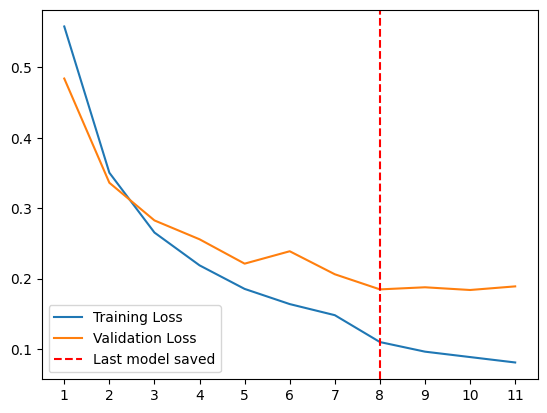

In [ ]:
plot_loss(training_losses=history["train_losses"], val_losses=history["val_losses"], last_model_saved_epoch=history['last_model_saved_epoch'])

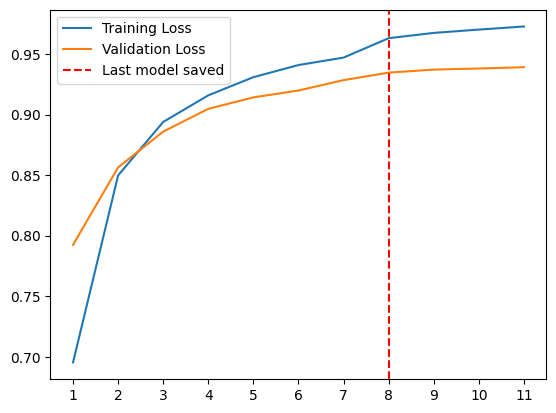

In [ ]:
plot_acc(training_accs=history["train_accs"], val_accs=history["val_accs"], last_model_saved_epoch=history['last_model_saved_epoch'])

In [ ]:
from google.colab import runtime
runtime.unassign()